In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2.1** Excercise 1

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(392.5), np.float64(324.5), np.float64(-0.5))

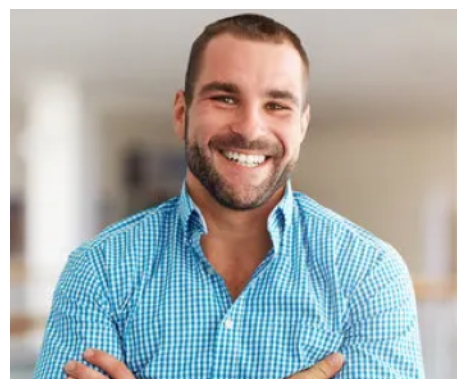

In [4]:
#For reading and displaying the image
image = Image.open("/content/drive/MyDrive/AI/Screenshot 2025-04-16 095730.png")
plt.imshow(image)
plt.axis("off")

Top left corner of 100 * 100 pixels


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

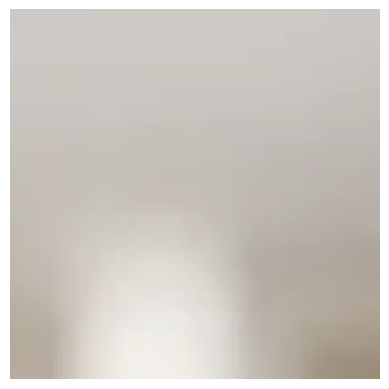

In [5]:
# For displaying top left corner of 100 * 100 pixels
img_array = np.array(image)
top_left = img_array[:100, :100]
print("Top left corner of 100 * 100 pixels")
plt.imshow(top_left)
plt.axis("off")

(325, 393, 4)


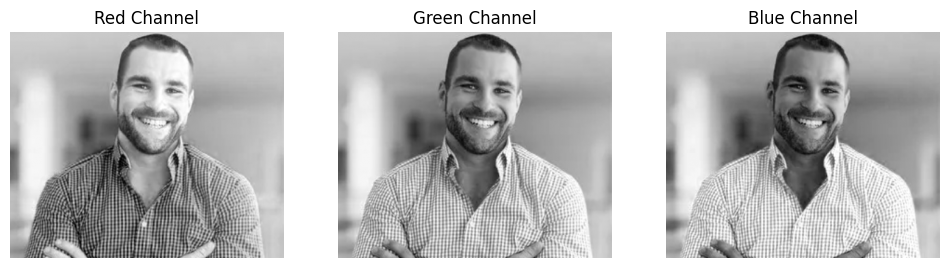

In [6]:
# For showing 3 color channels (R, G, B)
img_array = np.array(image)
print(img_array.shape)
# Separate channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]
plt.figure(figsize=(12,9))

plt.subplot(1,3,1)
plt.imshow(R, cmap='gray')
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(G, cmap='gray')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("Blue Channel")
plt.axis("off")

plt.show()

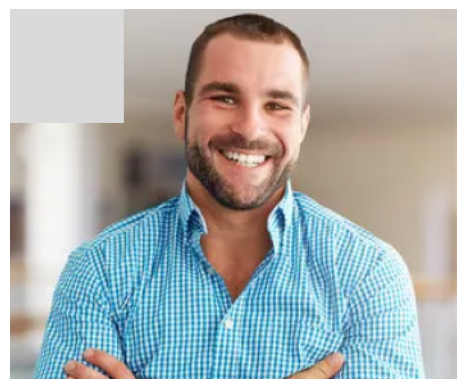

In [ ]:
# For modifying the top 100 × 100 pixels to a value of 210 and display the resulting image
img_array[:100, :100, :3] = 210  # :3 ensures only RGB channels, not alpha
plt.imshow(img_array)
plt.axis("off")
plt.show()

**2.2** Excercise 2

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(859.5), np.float64(1079.5), np.float64(-0.5))

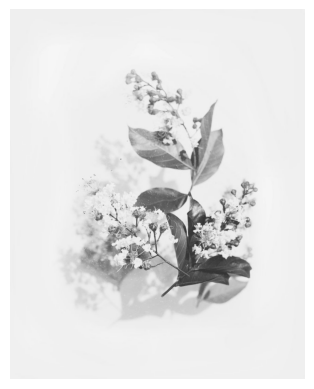

In [10]:
# Loading and displaying the image
image1 = Image.open("/content/drive/MyDrive/AI/ZkE9PQ.jpg")
plt.imshow(image1)
plt.axis("off")

1080 860


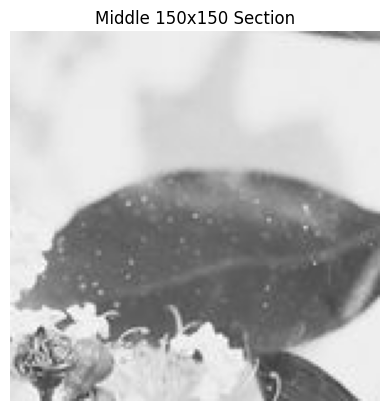

In [11]:
# Extracting and displaying middle section
img_array = np.array(image1)
#Check shape
height, width = img_array.shape[:2]
print(height, width)  # just to know dimensions
crop_size = 150

# Center coordinates
center_row = height // 2
center_col = width // 2

# Calculate start and end indices
start_row = center_row - crop_size // 2
end_row   = center_row + crop_size // 2

start_col = center_col - crop_size // 2
end_col   = center_col + crop_size // 2

middle_section = img_array[start_row:end_row, start_col:end_col, :]

plt.imshow(middle_section)
plt.axis("off")
plt.title("Middle 150x150 Section")
plt.show()

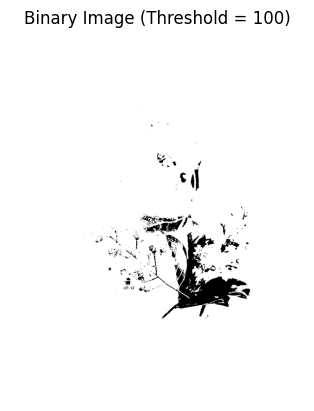

In [12]:
# For applying a simple threshold to the image (e.g., set all pixel values below 100 to 0).
image1 = Image.open("/content/drive/MyDrive/AI/ZkE9PQ.jpg").convert("L")
img_array = np.array(image1)
binary_image = np.where(img_array < 100, 0, 255)
plt.imshow(binary_image, cmap='gray')
plt.axis("off")
plt.title("Binary Image (Threshold = 100)")
plt.show()

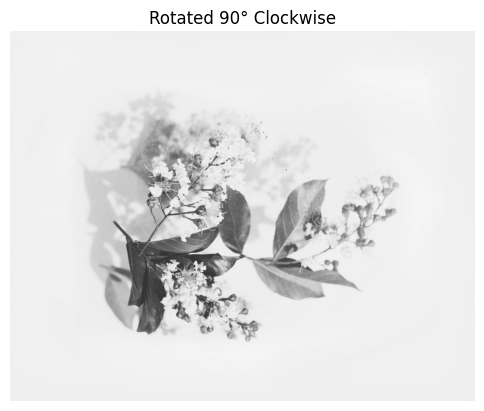

In [16]:
# Rotate 90 degrees clockwise
rotated = image1.rotate(-90, expand=True)

plt.imshow(rotated)
plt.axis("off")
plt.title("Rotated 90° Clockwise")
plt.show()

(1080, 860)
(1080, 860, 3)


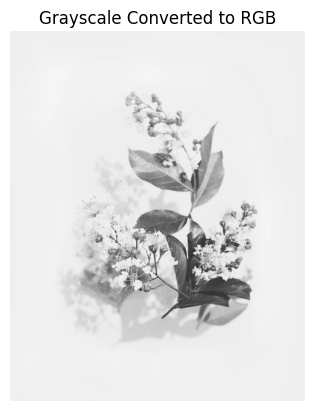

In [22]:
# For converting grayscale image into RGB
gray_image = Image.open("/content/drive/MyDrive/AI/ZkE9PQ.jpg").convert("L")

gray_array = np.array(gray_image)
print(gray_array.shape)

rgb_array = np.stack((gray_array,)*3, axis=-1)

print(rgb_array.shape)

plt.imshow(rgb_array)
plt.axis("off")
plt.title("Grayscale Converted to RGB")
plt.show()

**2.3** Excercise 3

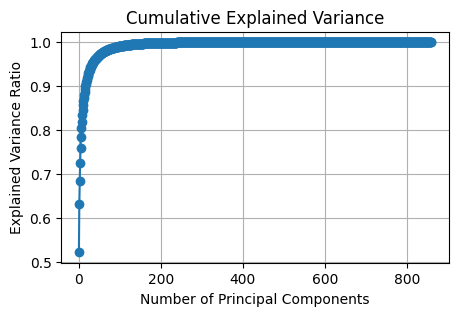

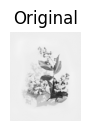

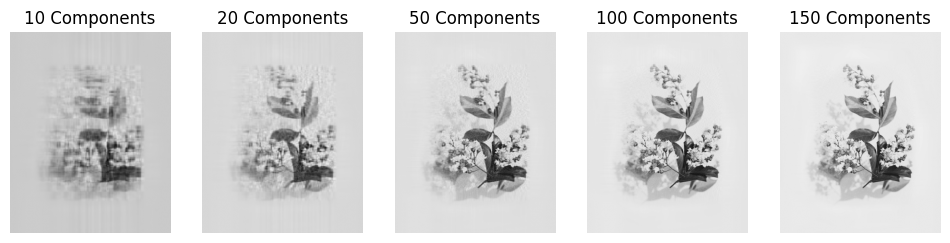

In [42]:

# Convert grayscale image to float
img_data = np.array(gray_image, dtype=float)

# Center data
X = img_data
X_centered = X - np.mean(X, axis=0)

# Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

# Sort eigenvalues descending
sorted_idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_idx]
eig_vecs = eig_vecs[:, sorted_idx]

# Cumulative explained variance
explained_variance = np.cumsum(eig_vals) / np.sum(eig_vals)
import matplotlib.pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(explained_variance, marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.grid()
plt.show()

# Function to reconstruct image using top k PCs
def reconstruct_image(X_centered, eig_vecs, k):
    top_k_eigvecs = eig_vecs[:, :k]
    X_reduced = np.dot(X_centered, top_k_eigvecs)
    X_reconstructed = np.dot(X_reduced, top_k_eigvecs.T) + np.mean(X, axis=0)
    return X_reconstructed

plt.subplot(1, len(k_values) + 1, 1)
plt.imshow(X, cmap='gray')
plt.title("Original")
plt.axis('off')

# Experiment with different k values
k_values = [10, 20, 50, 100, 150]
plt.figure(figsize=(12,3))
for i, k in enumerate(k_values):
    rec = reconstruct_image(X_centered, eig_vecs, k)
    plt.subplot(1,5,i+1)
    plt.imshow(rec, cmap='gray')
    plt.title(f"{k} Components")
    plt.axis('off')
plt.show()